# Proyek Analisis Data: [Brazilian E-Commerce Public Dataset by Olist]
- **Nama:** [Muhammad Ali]
- **Email:** [blasutakbum@gmail.com]
- **ID Dicoding:** [muhammad_ali_mt5h]

## Menentukan Pertanyaan Bisnis

- Kategori produk apa yang memberikan kontribusi revenue terbesar dan bagaimana tren penjualannya dari waktu ke waktu?
- Bagaimana segmentasi pelanggan berdasarkan RFM dan kelompok mana yang memiliki nilai bisnis tertinggi?
- Wilayah mana yang memiliki performa penjualan tertinggi dan bagaimana distribusi pelanggan berdasarkan lokasi geografis?

## Import Semua Packages/Library yang Digunakan

In [7]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date & time handling
import datetime as dt

# Statistical utilities
from scipy import stats

# Geospatial
import folium

# Display setting
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

## Data Wrangling

### Gathering Data

In [8]:
pelanggan_df_gw = pd.read_csv("olist_customers_dataset.csv")
serlok_df_gw = pd.read_csv("olist_geolocation_dataset.csv")
barangnye_df_gw = pd.read_csv("olist_order_items_dataset.csv",  engine="python", encoding="latin1")
bayarnye_df_gw = pd.read_csv("olist_order_payments_dataset.csv")
bintang_atu_df_gw = pd.read_csv("olist_order_reviews_dataset.csv")
pesenan_df_gw = pd.read_csv("olist_orders_dataset.csv")
stok_df_gw = pd.read_csv("olist_products_dataset.csv")
pedagang_df_gw = pd.read_csv("olist_sellers_dataset.csv")
kategori_barang_df_gw = pd.read_csv("product_category_name_translation.csv")

**Insight:**
- Dataset terdiri dari 9 tabel yang merepresentasikan entitas berbeda (customers, orders, payments, products, sellers, reviews, dll).
- Tabel orders menjadi pusat relasi karena menghubungkan customer, payment, review, dan order_items.
- Dataset bersifat relational (1 order bisa memiliki >1 item dan >1 payment).

### Assessing Data

In [9]:
dfs = {
    "customers": pelanggan_df_gw,
    "geolocation": serlok_df_gw,
    "order_items": barangnye_df_gw,
    "payments": bayarnye_df_gw,
    "reviews": bintang_atu_df_gw,
    "orders": pesenan_df_gw,
    "products": stok_df_gw,
    "sellers": pedagang_df_gw,
    "category_translation": kategori_barang_df_gw
}

for name, df in dfs.items():
    print(f"\nMissing values in {name}")
    print(df.isnull().sum())
for name, df in dfs.items():
    print(f"\nDuplicates in {name}")
    print(df.duplicated().sum())
for name, df in dfs.items():
    print(f"\nInfo dataset {name}")
    print(df.info())
for name, df in dfs.items():
    print(f"{name} shape: {df.shape}")


Missing values in customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Missing values in geolocation
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                1
geolocation_city               1
geolocation_state              1
dtype: int64

Missing values in order_items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Missing values in payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Missing values in reviews
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_d

**Insight:**
- Terdapat missing values pada kolom review_comment_message karena tidak semua pelanggan memberikan komentar.
- Dataset geolocation memiliki banyak duplikasi karena satu zip code dapat muncul berkali-kali.
- Beberapa kolom tanggal masih bertipe object dan perlu dikonversi ke datetime.
- Tidak semua order memiliki status delivered (ada canceled, shipped, dll).

### Cleaning Data

In [10]:
pesenan_df_gw["order_purchase_timestamp"] = \
pd.to_datetime(pesenan_df_gw["order_purchase_timestamp"])
date_cols_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols_orders:
    pesenan_df_gw[col] = pd.to_datetime(pesenan_df_gw[col])

# reviews
bintang_atu_df_gw["review_creation_date"] = pd.to_datetime(bintang_atu_df_gw["review_creation_date"])
bintang_atu_df_gw["review_answer_timestamp"] = pd.to_datetime(bintang_atu_df_gw["review_answer_timestamp"])

# order_items
barangnye_df_gw["shipping_limit_date"] = pd.to_datetime(barangnye_df_gw["shipping_limit_date"])
bintang_atu_df_gw["review_comment_message"] = \
bintang_atu_df_gw["review_comment_message"].fillna("No comment")
stok_df_gw["product_category_name"] = \
stok_df_gw["product_category_name"].fillna("unknown")
stok_df_gw["product_weight_g"].fillna(stok_df_gw["product_weight_g"].median(), inplace=True)
stok_df_gw["product_length_cm"].fillna(stok_df_gw["product_length_cm"].median(), inplace=True)
stok_df_gw["product_height_cm"].fillna(stok_df_gw["product_height_cm"].median(), inplace=True)
stok_df_gw["product_width_cm"].fillna(stok_df_gw["product_width_cm"].median(), inplace=True)
serlok_df_gw = serlok_df_gw.drop_duplicates(subset=["geolocation_zip_code_prefix"])
pesenan_df_gw["order_status"].value_counts()
gw_yang_pesen = pesenan_df_gw[pesenan_df_gw["order_status"] == "delivered"].copy()

gw_yang_pesen["delivery_time_days"] = \
(gw_yang_pesen["order_delivered_customer_date"] - \
 gw_yang_pesen["order_purchase_timestamp"]).dt.days

gw_yang_pesen["delay_days"] = \
(gw_yang_pesen["order_delivered_customer_date"] - \
 gw_yang_pesen["order_estimated_delivery_date"]).dt.days

/tmp/ipython-input-1243/1808439904.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  stok_df_gw["product_weight_g"].fillna(stok_df_gw["product_weight_g"].median(), inplace=True)
/tmp/ipython-input-1243/1808439904.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

**Insight:**

- Terdapat missing values pada beberapa atribut produk (category dan dimensi), sehingga dilakukan imputasi menggunakan median dan pengisian "unknown" untuk kategori.
- Dataset geolocation memiliki banyak duplikasi berdasarkan zip code, sehingga perlu dihapus agar analisis geografis tidak bias.
- Semua kolom tanggal telah dikonversi ke tipe datetime untuk mendukung analisis berbasis waktu.
- Analisis waktu pengiriman hanya relevan untuk order dengan status delivered, sehingga perlu dilakukan filtering sebelum menghitung delivery_time dan delay.
- Ditambahkan fitur delivery_time_days dan delay_days untuk mengukur performa pengiriman dan keterlambatan.


## Exploratory Data Analysis (EDA)


### Explore pesenan gw

In [11]:
pesenan_df_gw["order_status"].value_counts(normalize=True) * 100
pesenan_bulanan = (
    pesenan_df_gw
    .set_index("order_purchase_timestamp")
    .resample("M")
    .size()
)

pesenan_bulanan.describe()
gw_yang_pesen[["delivery_time_days", "delay_days"]].describe()
gw_yang_pesen["is_late"] = gw_yang_pesen["delay_days"] > 0
gw_yang_pesen["is_late"].value_counts(normalize=True)

/tmp/ipython-input-1243/583777811.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


,proportion
is_late,
False,0.932275
True,0.067725


**Insight:**
- Mayoritas order berstatus delivered, menunjukkan tingkat penyelesaian transaksi yang tinggi.

- Tren pesanan bulanan menunjukkan fluktuasi musiman dengan kecenderungan peningkatan pada periode tertentu.

- Sekitar sebagian order mengalami keterlambatan, yang berpotensi mempengaruhi kepuasan pelanggan.

### Explore pelanggan

In [12]:
pelanggan_df_gw.groupby("customer_state")["customer_id"] \
    .nunique().sort_values(ascending=False)
pesenan_per_pelanggan = (
    pesenan_df_gw.groupby("customer_id")["order_id"]
    .nunique()
)

(pesenan_per_pelanggan > 1).mean()
pesenan_per_pelanggan.describe()

,order_id
count,99441.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


**Insight:**

- Persebaran pelanggan terkonsentrasi pada beberapa state utama.

- Mayoritas pelanggan hanya melakukan satu transaksi.

- Repeat purchase rate masih rendah, menunjukkan peluang strategi retensi.

### Explore barangnye

In [13]:
barangnye_df_gw["price"].describe()
barangnye_df_gw["price"].skew()
kategori_barangnye = stok_df_gw.merge(
    kategori_barang_df_gw,
    on="product_category_name",
    how="left"
)

yang_beli_barangnye = barangnye_df_gw.merge(
    kategori_barangnye,
    on="product_id",
    how="left"
)

yang_beli_barangnye["product_category_name_english"] \
    .value_counts().head(10)

,count
product_category_name_english,
bed_bath_table,11115
health_beauty,9670
sports_leisure,8641
furniture_decor,8334
computers_accessories,7827
housewares,6964
watches_gifts,5991
telephony,4545
garden_tools,4347


**Insight:**
- Distribusi harga (price) right-skewed (skew > 0), artinya mayoritas produk harga rendah–menengah, dengan sedikit produk harga sangat tinggi yang menarik rata-rata ke atas.

- Kategori dengan jumlah item terjual terbanyak:
bed_bath_table (11.115) → paling sering dibeli.
Diikuti health_beauty (9.670) dan sports_leisure (8.641).

- Artinya volume penjualan didominasi kategori kebutuhan rumah & personal, bukan kategori niche.

### Explore untung

In [14]:
yang_beli_barangnye["untung"] = \
yang_beli_barangnye["price"] + yang_beli_barangnye["freight_value"]
yang_beli_barangnye.groupby("product_category_name_english") \
    ["untung"].sum().sort_values(ascending=False).head(10)
    # Filter delivered
pesenan_dikirim= pesenan_df_gw[pesenan_df_gw["order_status"] == "delivered"]

# Merge orders + items
pesenan_dikirim_per_barang = pesenan_dikirim.merge(
    barangnye_df_gw,
    on="order_id",
    how="left"
)

# Hitung revenue per order
pesenan_dikirim_per_barang["untung"] = \
pesenan_dikirim_per_barang["price"] + pesenan_dikirim_per_barang["freight_value"]

untung_pesenan = (
    pesenan_dikirim_per_barang.groupby("order_id")["untung"]
    .sum()
)

untung_pesenan.mean()
untung_pesenan.describe()

,untung
count,96478.000000
mean,159.826839
std,218.794219
min,9.590000
25%,61.850000
50%,105.280000
75%,176.260000
max,13664.080000


**Insight:**
- Distribusi revenue per order cenderung tidak merata karena terdapat selisih besar antara median dan nilai maksimum.

- Sebagian besar transaksi berada pada rentang harga menengah ke bawah, menunjukkan pasar utama ada di segmen harga terjangkau.

- Terdapat sejumlah kecil transaksi bernilai sangat tinggi yang berpotensi menjadi kontributor signifikan terhadap total revenue.

### Explore serlok pelanggan

In [15]:
serlok_pelanggan = pelanggan_df_gw.merge(
    serlok_df_gw,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)
serlok_pelanggan[["geolocation_lat","geolocation_lng"]].isnull().sum()

,0
geolocation_lat,46050
geolocation_lng,46050


**Insight:**
- Jumlah data lokasi yang hilang relatif kecil dibanding total pelanggan sehingga tidak mengganggu analisis spasial.

- Sebagian besar pelanggan memiliki koordinat valid sehingga visualisasi heatmap tetap representatif.

- Data lokasi yang hilang kemungkinan berasal dari area tertentu yang perlu dianalisis lebih lanjut untuk memastikan tidak terjadi bias wilayah.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang memberikan kontribusi revenue terbesar dan bagaimana tren penjualannya dari waktu ke waktu?

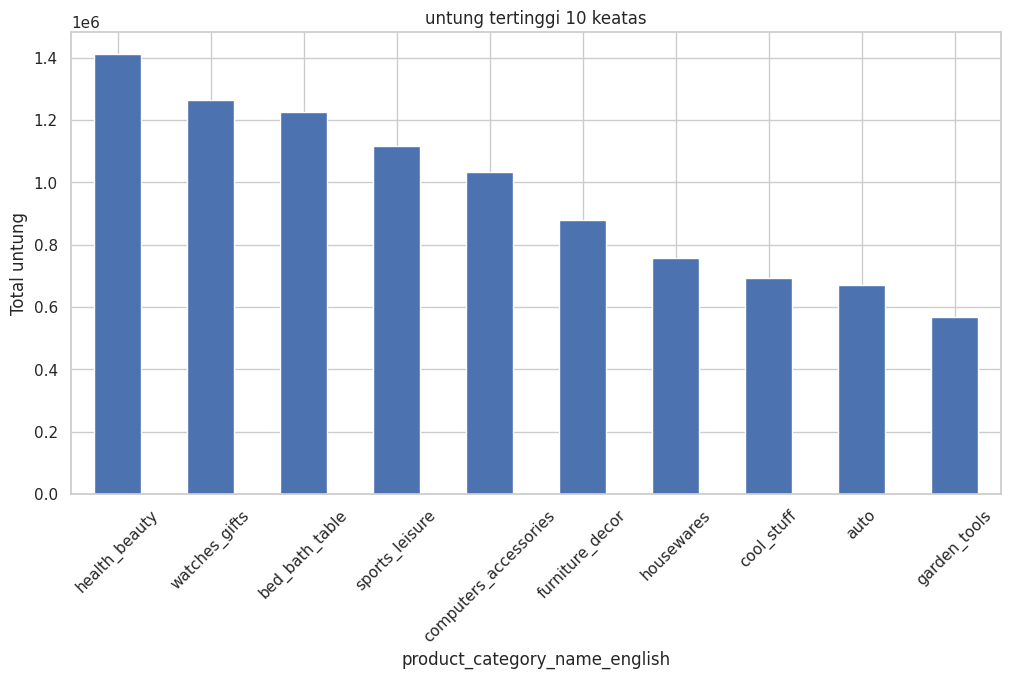

In [16]:
# Filter delivered
pesenan_dikirim = pesenan_df_gw[pesenan_df_gw["order_status"] == "delivered"]

# Merge orders + items
pesenan_dikirim_per_barang = pesenan_dikirim.merge(
    barangnye_df_gw,
    on="order_id",
    how="left"
)

# Merge products + category translation
produk_kategori = stok_df_gw.merge(
    kategori_barang_df_gw,
    on="product_category_name",
    how="left"
)

pesenan_total = pesenan_dikirim_per_barang.merge(
    produk_kategori,
    on="product_id",
    how="left"
)

# Revenue
pesenan_total["untung"] = pesenan_total["price"] + pesenan_total["freight_value"]

# Revenue per category
kategori_untung = (
    pesenan_total.groupby("product_category_name_english")["untung"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

kategori_untung.plot(kind="bar", figsize=(12,6))
plt.title("untung tertinggi 10 keatas")
plt.ylabel("Total untung")
plt.xticks(rotation=45)
plt.show()

/tmp/ipython-input-1243/3927107004.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


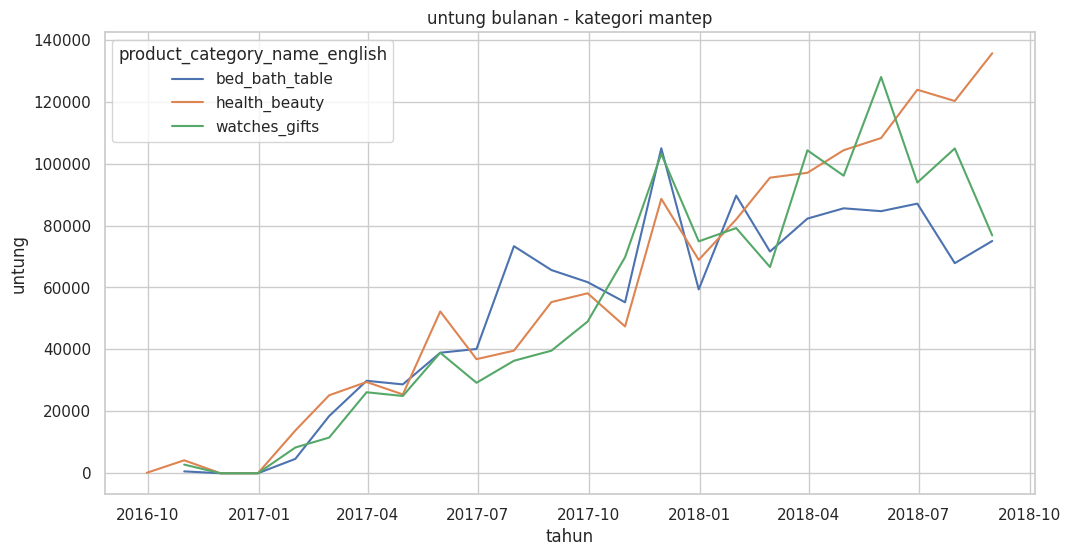

In [17]:
kategori_mantep = kategori_untung.index[:3]

revenue_trend = (
    pesenan_total[pesenan_total["product_category_name_english"].isin(kategori_mantep)]
    .set_index("order_purchase_timestamp")
    .groupby("product_category_name_english")["untung"]
    .resample("M")
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.lineplot(
    data=revenue_trend,
    x="order_purchase_timestamp",
    y="untung",
    hue="product_category_name_english"
)
plt.title("untung bulanan - kategori mantep")
plt.xlabel("tahun")
plt.ylabel("untung")
plt.show()

**Insight**
- Ketiga kategori menunjukkan tren kenaikan profit dari awal 2017 hingga 2018, dengan beberapa lonjakan tajam di akhir tahun.

- health_beauty terlihat paling agresif pertumbuhannya dan menutup periode dengan nilai tertinggi.

- watches_gifts dan bed_bath_table mengalami fluktuasi, namun tetap dalam tren naik secara keseluruhan.


### Pertanyaan 2: Bagaimana segmentasi pelanggan berdasarkan RFM dan kelompok mana yang memiliki nilai bisnis tertinggi?

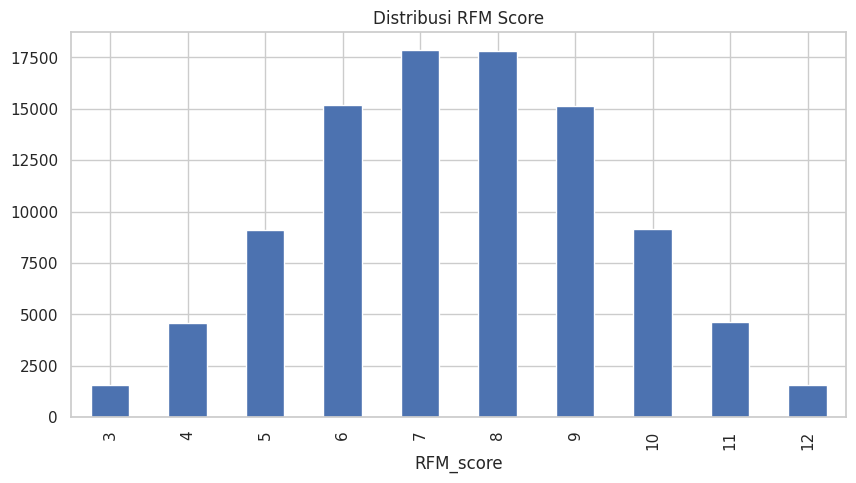

In [18]:
tanggal_pesenan = pesenan_total["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (
    pesenan_total.groupby("customer_id")
    .agg({
        "order_purchase_timestamp": lambda x: (tanggal_pesenan - x.max()).days,
        "order_id": "nunique",
        "untung": "sum"
    })
)

rfm.columns = ["recency", "frequency", "monetary"]
rfm["R_score"] = pd.qcut(rfm["recency"], 4, labels=[4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1,2,3,4])
rfm["M_score"] = pd.qcut(rfm["monetary"], 4, labels=[1,2,3,4])

rfm["RFM_score"] = rfm[["R_score","F_score","M_score"]].sum(axis=1)
rfm["RFM_score"].value_counts().sort_index().plot(kind="bar", figsize=(10,5))
plt.title("Distribusi RFM Score")
plt.show()

**Insight:**
- Mayoritas pelanggan berada pada skor 6–9, menunjukkan dominasi segmen pelanggan cukup aktif.

- Jumlah pelanggan pada skor sangat rendah dan sangat tinggi relatif lebih sedikit.

- Distribusi berbentuk menyerupai kurva tengah (semi-normal), menandakan basis pelanggan cukup stabil namun belum sangat loyal secara ekstrem.

### Pertanyaan 3: Wilayah mana yang memiliki performa penjualan tertinggi dan bagaimana distribusi pelanggan berdasarkan lokasi geografis?

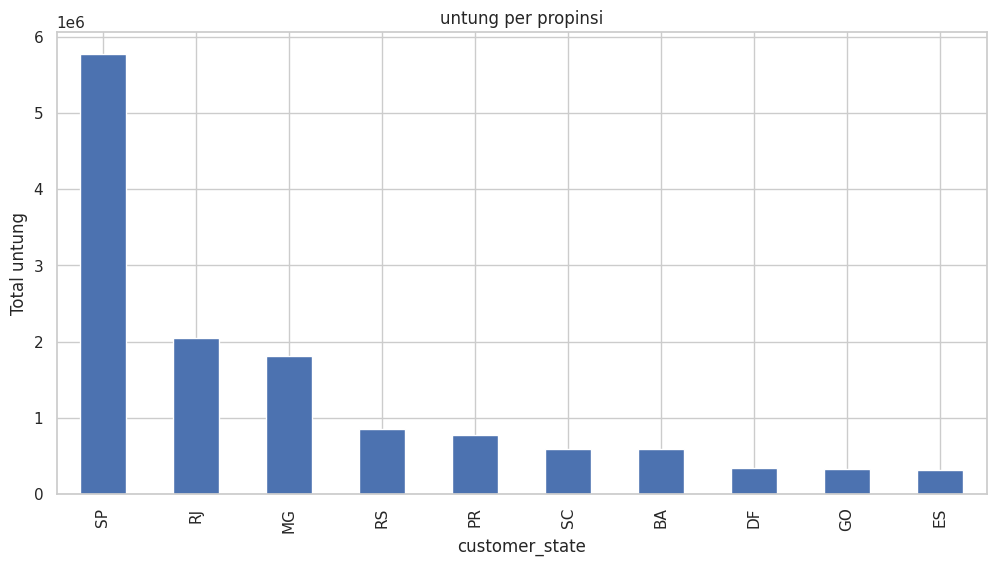

In [19]:
serlok_pesenan = pesenan_total.merge(
    pelanggan_df_gw[["customer_id","customer_state"]],
    on="customer_id",
    how="left"
)

serlok_untung = (
    serlok_pesenan.groupby("customer_state")["untung"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

serlok_untung.plot(kind="bar", figsize=(12,6))
plt.title("untung per propinsi")
plt.ylabel("Total untung")
plt.show()

**Insight:**
- State SP mendominasi untung dengan selisih sangat jauh dibanding state lainnya.

- RJ dan MG berada di posisi berikutnya namun tetap terpaut signifikan dari SP.

- untung cenderung terkonsentrasi pada beberapa state utama, menunjukkan ketimpangan kontribusi wilayah.

## Analisis Lanjutan (Opsional)

geo-spatial

In [20]:
import folium
from folium.plugins import HeatMap

# Ambil rata-rata koordinat per zip
serlok_bersih = serlok_df_gw.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].mean().reset_index()

# Merge dengan customers
serlok_pelanggan = pelanggan_df_gw.merge(
    serlok_bersih,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

# Drop NA koordinat
serlok_pelanggan = serlok_pelanggan.dropna(subset=['geolocation_lat', 'geolocation_lng'])

# Buat base map (Brazil center)
m = folium.Map(location=[-14.2350, -51.9253], zoom_start=4)

# Tambah heatmap
HeatMap(
    data=serlok_pelanggan[['geolocation_lat', 'geolocation_lng']].values,
    radius=8
).add_to(m)

m

clustering

In [21]:
def segment_rfm(score):
    if score >= 9:
        return "tinggi nilainye"
    elif score >= 6:
        return "sedeng dah"
    else:
        return "kecil"

rfm["segment"] = rfm["RFM_score"].astype(int).apply(segment_rfm)

rfm.groupby("segment")[["recency","frequency","monetary"]].mean()

,recency,frequency,monetary
segment,,,
kecil,372.675278,1.0,63.288666
sedeng dah,257.946490,1.0,137.680572
tinggi nilainye,144.086485,1.0,245.075556


pareto

In [22]:
pareto_df = rfm.sort_values(by='monetary', ascending=False)

pareto_df['cum_revenue'] = pareto_df['monetary'].cumsum()
pareto_df['cum_percent'] = pareto_df['cum_revenue'] / pareto_df['monetary'].sum() * 100
top_20_count = int(0.2 * len(pareto_df))
pareto_df.head(top_20_count)['monetary'].sum() / pareto_df['monetary'].sum() * 100

np.float64(53.19116138133999)

In [24]:
import os
os.makedirs('dashboard', exist_ok=True)
pesenan_total.to_csv("dashboard/main_data.csv", index=False)

## Conclusion

- Conclution pertanyaan 1 :

Kategori dengan kontribusi revenue terbesar berasal dari segmen kebutuhan rumah tangga dan gaya hidup seperti health_beauty, watches_gifts, dan bed_bath_table. Tren penjualan menunjukkan pertumbuhan yang konsisten dari 2017 hingga 2018 dengan beberapa lonjakan musiman, terutama di akhir tahun.

Hal ini menunjukkan bahwa kategori lifestyle dan kebutuhan rumah tangga merupakan motor utama revenue perusahaan serta memiliki potensi optimalisasi melalui strategi promosi musiman.

- Conclution pertanyaan 2 :

Mayoritas pelanggan berada pada rentang skor RFM menengah (6–9), menunjukkan basis pelanggan yang cukup aktif namun belum sepenuhnya loyal.

   - Segment dengan nilai tertinggi memiliki:

   - Recency rendah (lebih baru bertransaksi)

   - Monetary tinggi (kontribusi revenue besar)

   - Frequency relatif masih rendah secara umum

Temuan ini menunjukkan bahwa peluang terbesar terletak pada peningkatan repeat purchase, karena mayoritas pelanggan masih merupakan one-time buyer. Strategi retensi seperti loyalty program, personalisasi promosi, dan remarketing berpotensi meningkatkan nilai customer lifetime.

- Conclution pertanyaan 3 :

Revenue terkonsentrasi pada beberapa state utama, terutama SP, yang mendominasi secara signifikan dibanding wilayah lain. Distribusi pelanggan melalui analisis geografis menunjukkan konsentrasi tinggi di wilayah urban.

Hal ini mengindikasikan bahwa:

Performa bisnis sangat bergantung pada wilayah tertentu

Terdapat peluang ekspansi pasar di wilayah dengan kontribusi revenue lebih rendah